<a href="https://colab.research.google.com/github/tamarakalashnyk20-glitch/ecommerce-customer-analytics/blob/main/Sales%26Customer_Behavior_Team_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sales Analytics and Customer Behavior
[Link for Tableau Dashboard](https://public.tableau.com/views/Teamproject_SalesCustomerBehavior/Dashboard3?:language=en-GB&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate_homework

Mounted at /content/drive
/content/drive/MyDrive/Mate_homework


In [ ]:
# Uploading datasets
df = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")

#Basics overview info

In [ ]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [ ]:
#Statistical summary
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


In [ ]:
df.shape

(17049, 18)

In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

#Data Quality Analysis

This section evaluates the dataset structure, missing values, duplicates, and feature integrity before conducting behavioral analytics and dashboard development.

In [ ]:
# Converting column names to lowercase.
df.columns = df.columns.str.lower()
df.columns = df.columns.str.strip()

In [ ]:
#Missing Value Check
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Missing Percentage': (missing_values.values / len(df)) * 100
})

missing_df.sort_values(by='Missing Values', ascending=False)

,Column,Missing Values,Missing Percentage
0,order_id,0,0.0
1,customer_id,0,0.0
2,date,0,0.0
3,age,0,0.0
4,gender,0,0.0
5,city,0,0.0
6,product_category,0,0.0
7,unit_price,0,0.0
8,quantity,0,0.0
9,discount_amount,0,0.0


In [ ]:
#Duplicate Check
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()


In [ ]:
#Convert date
df["date"] = pd.to_datetime(df["date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  17049 non-null  object        
 1   customer_id               17049 non-null  object        
 2   date                      17049 non-null  datetime64[ns]
 3   age                       17049 non-null  int64         
 4   gender                    17049 non-null  object        
 5   city                      17049 non-null  object        
 6   product_category          17049 non-null  object        
 7   unit_price                17049 non-null  float64       
 8   quantity                  17049 non-null  int64         
 9   discount_amount           17049 non-null  float64       
 10  total_amount              17049 non-null  float64       
 11  payment_method            17049 non-null  object        
 12  device_type       

In [ ]:
#Time features
df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

df['day_of_week'] = df['date'].dt.day_name()

df['quarter'] = df['date'].dt.quarter

#BUSINESS FEATURES

In [ ]:
#Revenue before discount
df['revenue_before_discount'] = (
    df['unit_price'] * df['quantity']
)

In [ ]:
#Discount percentage
df['discount_percentage'] = (
    df['discount_amount']
    /
    df['revenue_before_discount']
) * 100

In [ ]:
#Average item value
df['avg_item_value'] = (
    df['total_amount'] / df['quantity']
)

#CUSTOMER FEATURES

In [ ]:
#Engagement score
df['engagement_score'] = (
    df['session_duration_minutes'] * 0.5
    +
    df['pages_viewed'] * 0.5
)

In [ ]:
#High rating flag
df['high_rating_flag'] = np.where(
    df['customer_rating'] >= 4,
    1,
    0
)

In [ ]:
#Recency
latest_date = df['date'].max()

df['recency_days'] = (
    latest_date - df['date']
).dt.days

EXPLORATORY DATA ANALYSIS

Structure:
1. Revenue Analysis
2. Customer Analysis
3. Product Analysis
4. Behavioral Analysis
5. Satisfaction Analysis
6. Correlation Analysis
7. Geographic Analysis

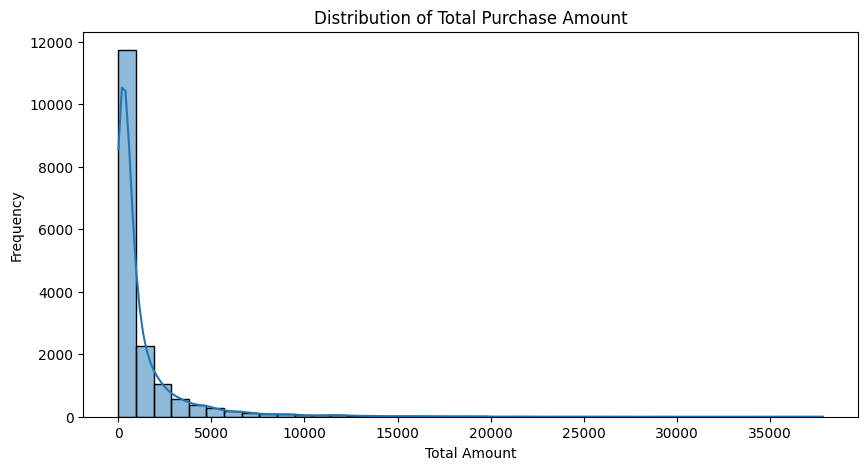

In [ ]:
#Distribution of Purchase Amounts
plt.figure(figsize=(10,5))

sns.histplot(
    df['total_amount'],
    bins=40,
    kde=True
)

plt.title('Distribution of Total Purchase Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.show()

The purchase amount distribution is heavily right-skewed.
Most transactions are relatively small, while a limited number
of high-value purchases contribute significantly to total revenue.

This pattern is common in e-commerce datasets and suggests
the presence of premium or bulk purchases.


In [ ]:
monthly_sales = (
    df.groupby('month_name')['total_amount']
    .sum()
    .reset_index()
)

In [ ]:
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_sales['month_name'] = pd.Categorical(
    monthly_sales['month_name'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('month_name')

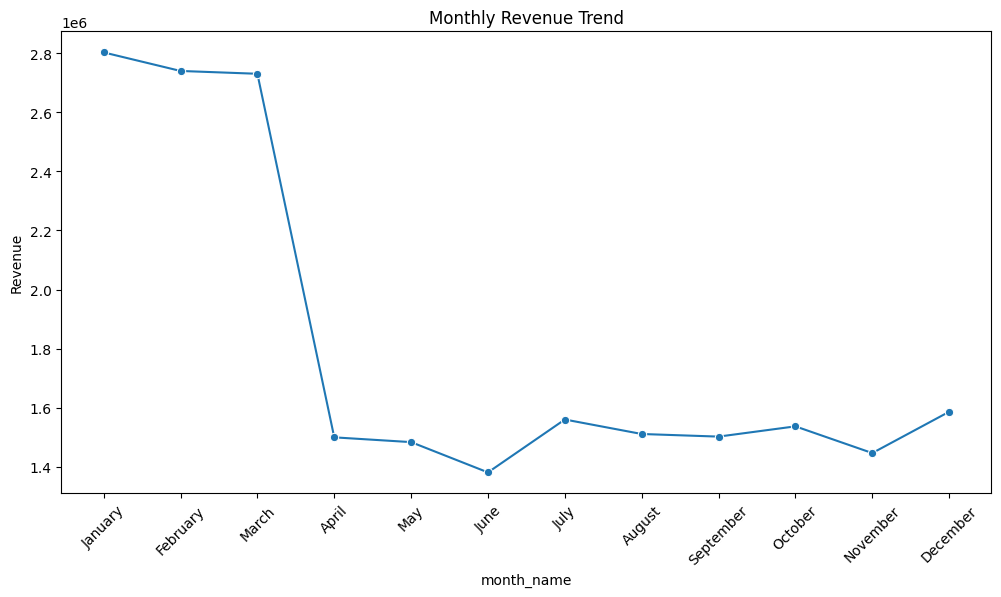

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='month_name',
    y='total_amount',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.show()

Revenue demonstrates a strong seasonal pattern.

The first quarter (January–March) generated significantly
higher revenue compared to the rest of the year.

Starting from April, revenue dropped sharply and stabilized
at a lower level throughout the remaining months.

This may indicate:
- seasonal purchasing behavior,
- post-holiday decline,
- or changes in transaction volume and customer spending.

#PRODUCT ANALYSIS
Which categories bring in the most revenue?

Which categories have the most expensive products?

In [ ]:
#Revenue by Product
category_sales = (
    df.groupby('product_category')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

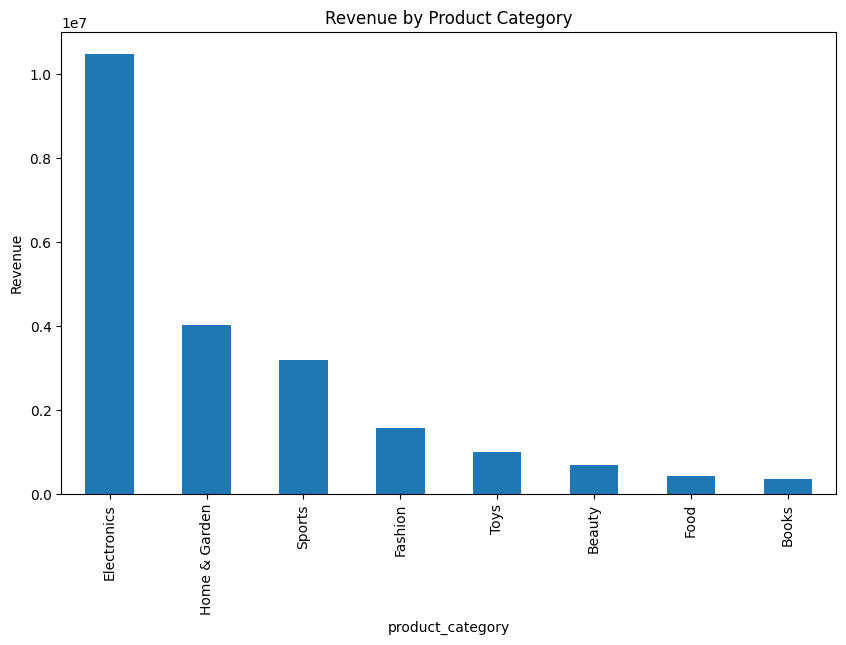

In [ ]:
#Revenue by Product Category Plot
plt.figure(figsize=(10,6))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.ylabel('Revenue')

plt.show()

In [ ]:
#Average Item Value by Category
avg_item = (
    df.groupby('product_category')['avg_item_value']
    .mean()
    .sort_values(ascending=False)
)

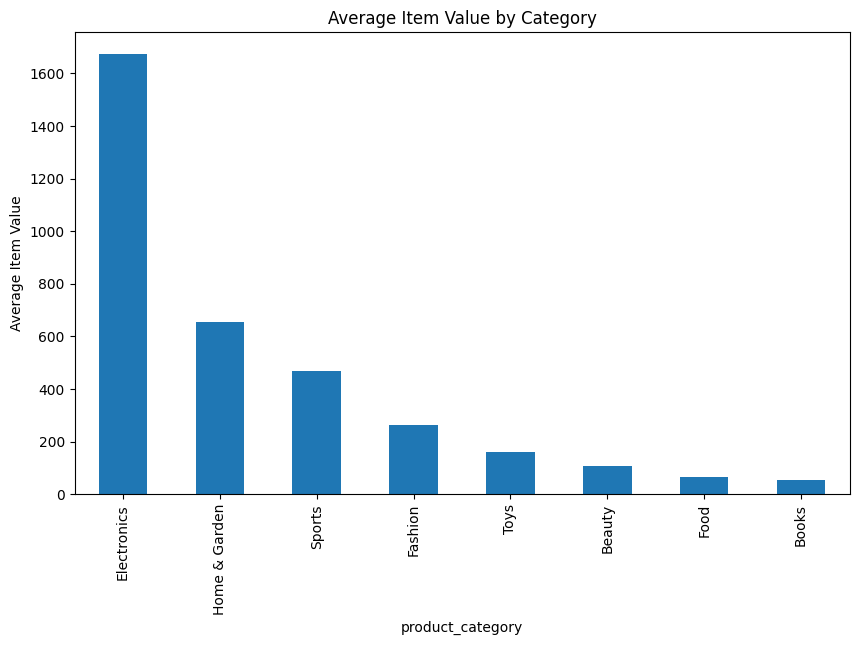

In [ ]:
#Average Item Value by Category Plot
plt.figure(figsize=(10,6))

avg_item.plot(kind='bar')

plt.title('Average Item Value by Category')
plt.ylabel('Average Item Value')

plt.show()

##CUSTOMER ANALYSIS
What is the main age group of customers?

In [ ]:
#Creating Age Groups
bins = [18, 25, 35, 45, 55, 65, 80]

labels = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

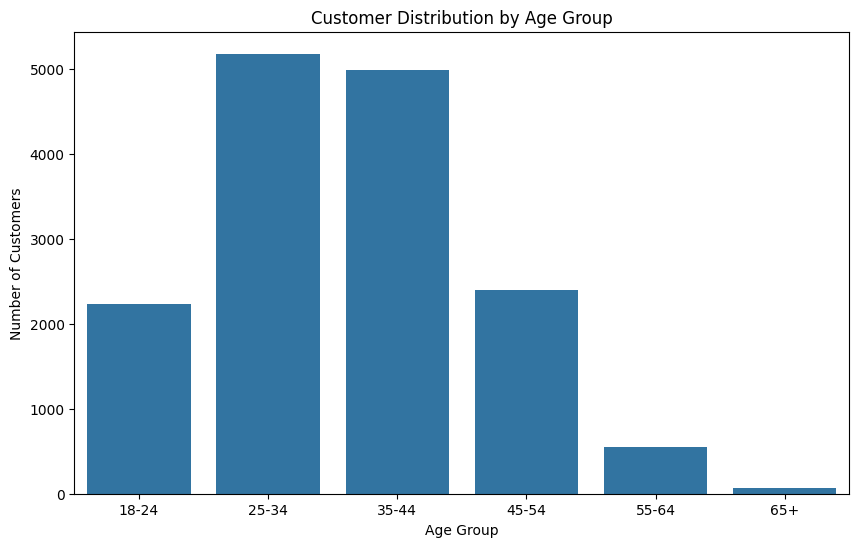

In [ ]:
#Customer Distribution by Age Group Plot
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='age_group',
    order=labels
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
#Revenue by Age Group
age_revenue = (
    df.groupby('age_group')['total_amount']
    .mean()
    .reset_index()
)

/tmp/ipykernel_7715/2613884532.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['total_amount']


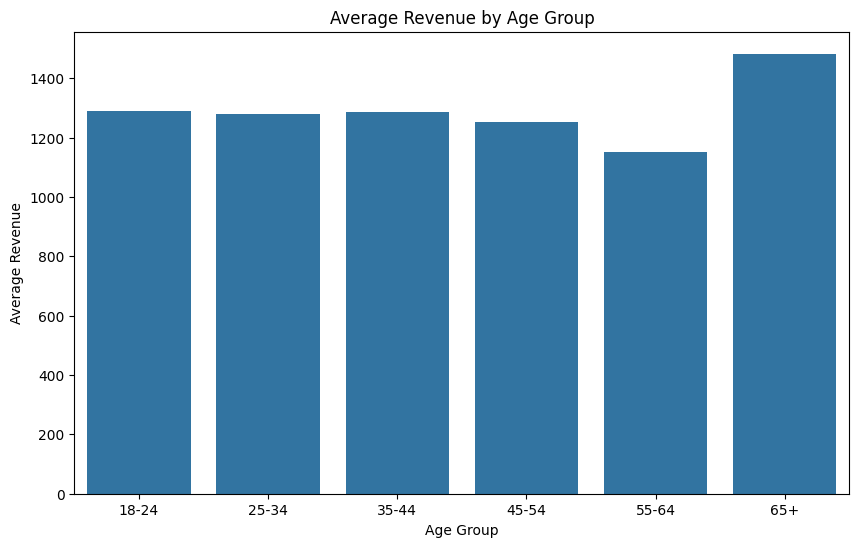

In [ ]:
#Average Revenue by Age Group Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=age_revenue,
    x='age_group',
    y='total_amount',
    order=labels
)

plt.title('Average Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Revenue')

plt.show()

Although younger customers generate the highest transaction volume,
the 65+ customer segment demonstrates the highest average spending.

This suggests that older customers may represent a smaller but
more valuable premium customer segment.

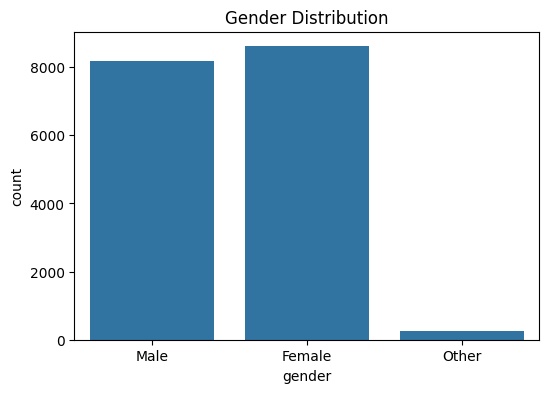

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Gender Distribution')

plt.show()

In [ ]:
returning_analysis = (
    df.groupby('is_returning_customer')['total_amount']
    .mean()
)

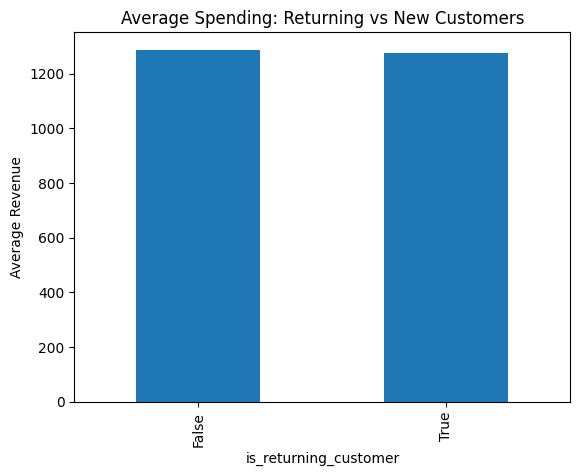

In [ ]:
returning_analysis.plot(kind='bar')

plt.title('Average Spending: Returning vs New Customers')

plt.ylabel('Average Revenue')

plt.show()

##BEHAVIORAL ANALYSIS


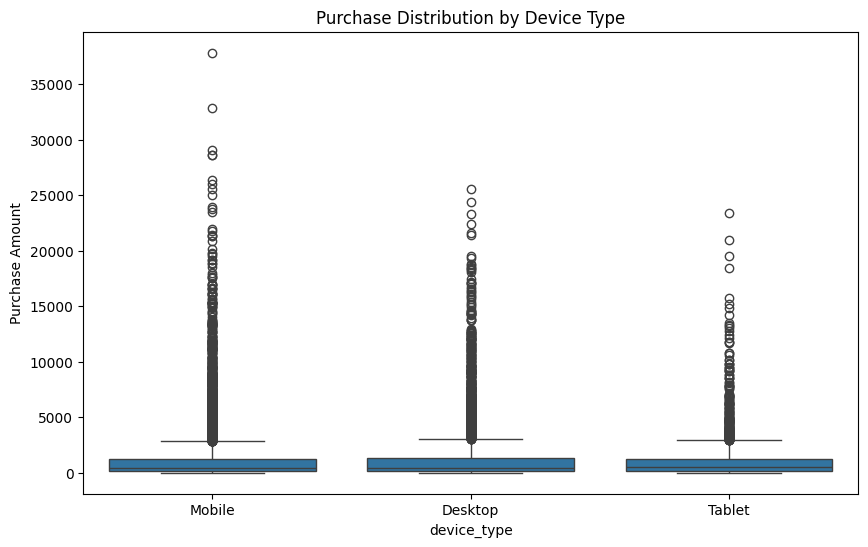

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='device_type',
    y='total_amount'
)

plt.title('Purchase Distribution by Device Type')

plt.ylabel('Purchase Amount')

plt.show()

Purchase distributions are highly right-skewed across all device types,
indicating the presence of high-value transactions.

Mobile users demonstrate the largest number of extreme purchase outliers,
suggesting that mobile platforms may also support premium transactions,
not only low-value quick purchases.

Overall median purchase behavior remains relatively consistent across devices.

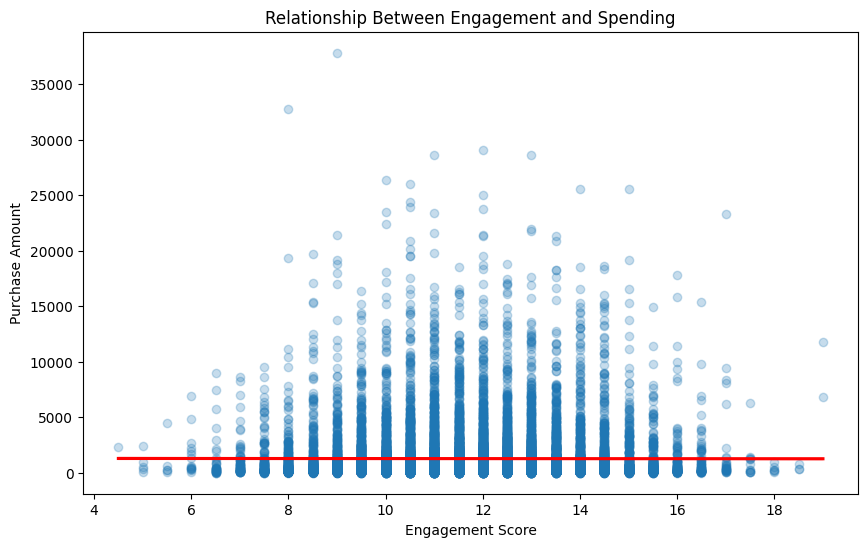

In [ ]:
#Relationship Between Engagement and Spending
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='engagement_score',
    y='total_amount',
    scatter_kws={'alpha':0.25},
    line_kws={'color':'red'}
)

plt.title('Relationship Between Engagement and Spending')

plt.xlabel('Engagement Score')
plt.ylabel('Purchase Amount')

plt.show()

The relationship between engagement and spending appears
to be relatively weak but slightly positive.

Customers with higher engagement scores demonstrate
greater spending variability and are more likely to
generate high-value transactions.

However, engagement alone is not a strong predictor
of purchase amount.

##SATISFACTION ANALYSIS


In [ ]:
delivery_rating = (
    df.groupby('delivery_time_days')['customer_rating']
    .mean()
    .reset_index()
)

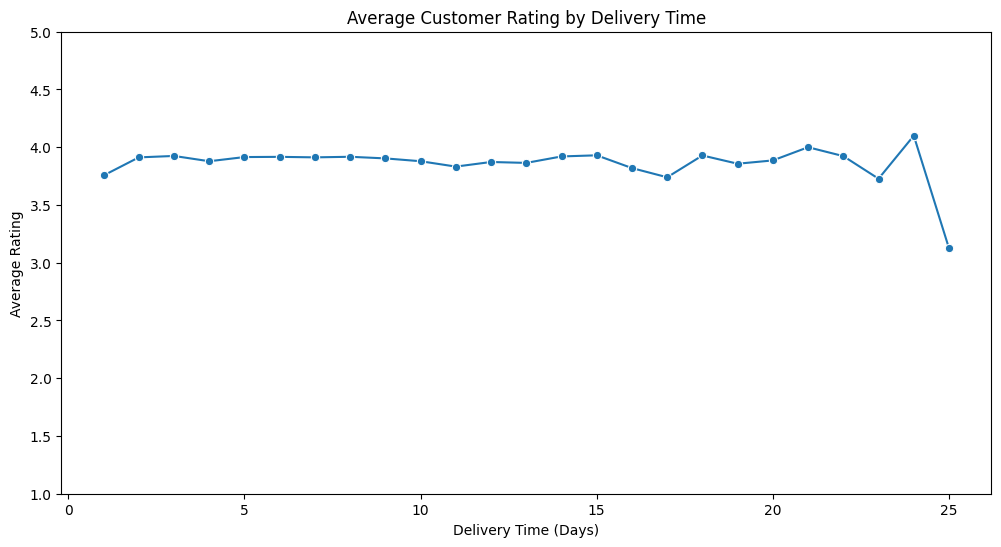

In [ ]:
#Delivery Time vs Customer Rating
plt.figure(figsize=(12,6))

sns.lineplot(
    data=delivery_rating,
    x='delivery_time_days',
    y='customer_rating',
    marker='o'
)

plt.title('Average Customer Rating by Delivery Time')

plt.xlabel('Delivery Time (Days)')
plt.ylabel('Average Rating')

plt.ylim(1,5)

plt.show()

Customer ratings remain relatively stable across most delivery times,
suggesting that delivery speed may not be a primary driver of satisfaction
in this dataset.

However, ratings for extremely long delivery times appear lower,
although these observations may be influenced by smaller sample sizes.

##CORRELATION ANALYSIS

In [ ]:
numeric_cols = [
    'age',
    'unit_price',
    'quantity',
    'discount_amount',
    'total_amount',
    'session_duration_minutes',
    'pages_viewed',
    'delivery_time_days',
    'customer_rating',
    'engagement_score',
    'avg_item_value'
]

In [ ]:
corr = df[numeric_cols].corr()

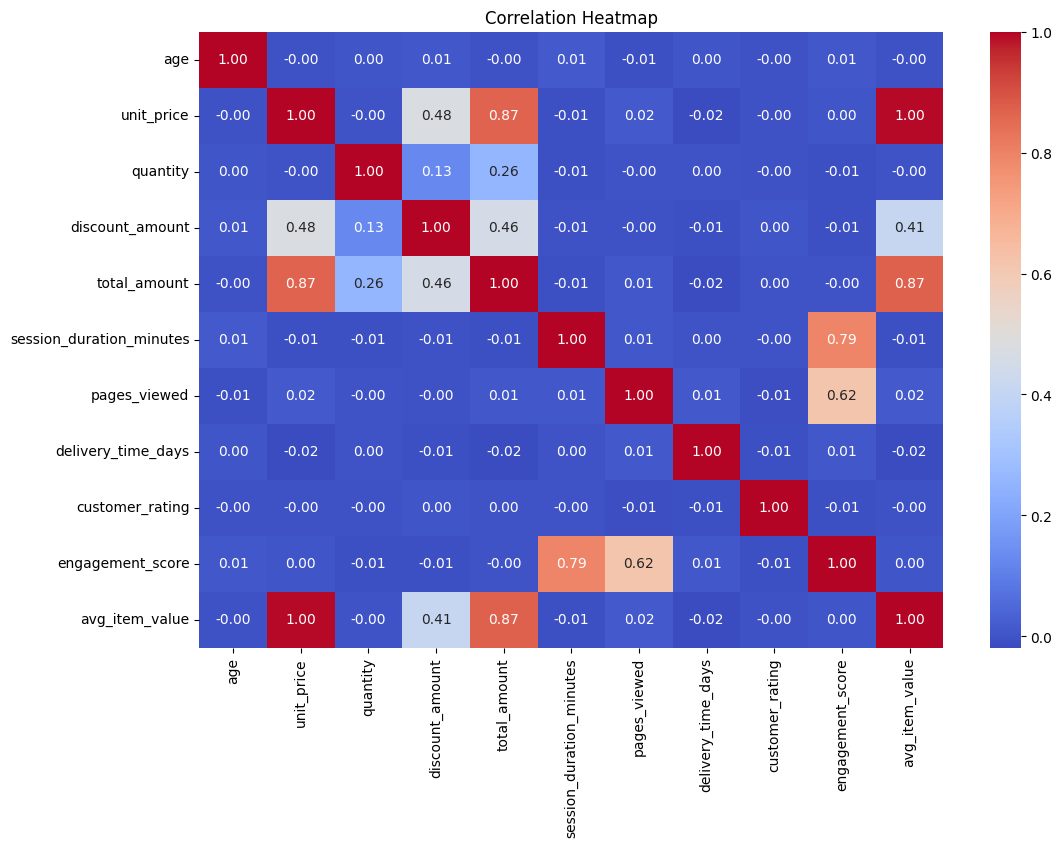

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Key correlation insights:

- Product price strongly influences total purchase amount.
- Engagement score is highly associated with session duration and browsing activity.
- Customer ratings show minimal correlation with transactional metrics,
  suggesting that satisfaction may depend on additional factors not captured in the dataset.
- Discounts moderately correlate with purchase amount, indicating that
  larger transactions tend to receive higher discounts.

##GEOGRAPHIC ANALYSIS

In [ ]:
city_sales = (
    df.groupby('city')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

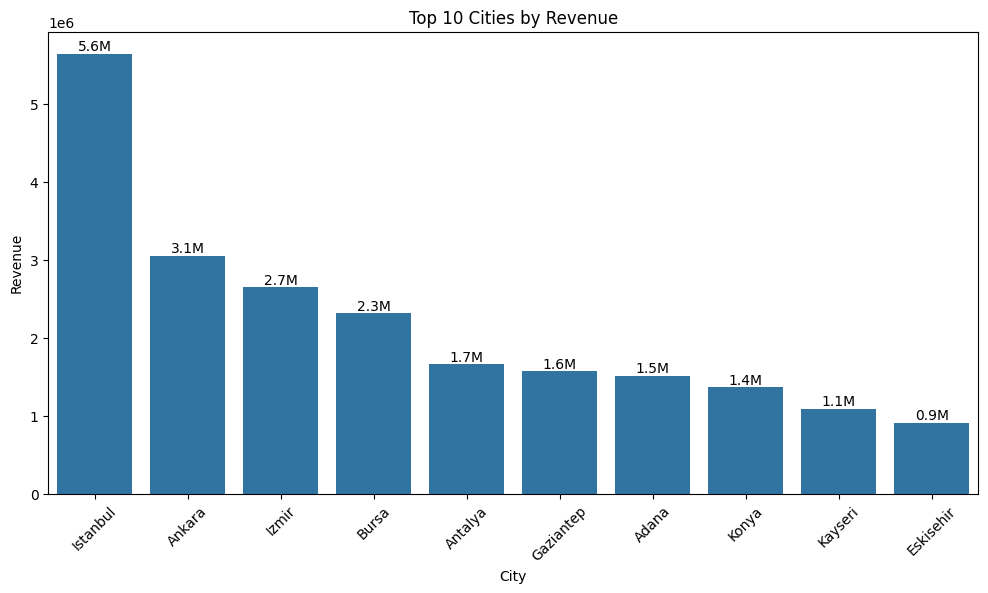

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=city_sales.reset_index(),
    x='city',
    y='total_amount'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()/1e6:.1f}M',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Top 10 Cities by Revenue')

plt.xlabel('City')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

Revenue is heavily concentrated in Istanbul,
which significantly outperforms all other cities.

Ankara and Izmir form the second strongest revenue tier,
while smaller cities contribute substantially lower revenue volumes.

This distribution suggests a highly centralized customer market.

##Customer Segmentation

1. Customer-level aggregation
2. Behavioral metrics
3. Rule-based segmentation
4. Visualization


In [ ]:
#Creating customer table
customer_analysis = (
    df.groupby('customer_id')
    .agg({
        'total_amount':'sum',
        'order_id':'count',
        'engagement_score':'mean',
        'discount_percentage':'mean',
        'customer_rating':'mean',
        'quantity':'sum',
        'recency_days':'min'
    })
    .reset_index()
)

In [ ]:
#Cleaning column names
customer_analysis.columns = [
    'customer_id',
    'lifetime_value',
    'total_orders',
    'avg_engagement',
    'avg_discount',
    'avg_rating',
    'total_items',
    'recency_days'
]

In [ ]:
customer_analysis.head()

,customer_id,lifetime_value,total_orders,avg_engagement,avg_discount,avg_rating,total_items,recency_days
0,CUST_00001,2199.63,3,11.666667,7.141010,3.333333,7,111
1,CUST_00002,809.90,2,12.500000,10.252525,4.000000,8,283
2,CUST_00003,3030.81,2,9.500000,0.000000,3.500000,7,82
3,CUST_00004,383.22,1,15.500000,20.328482,5.000000,5,41
4,CUST_00005,2422.73,3,11.000000,0.000000,3.666667,8,278


In [ ]:
customer_analysis.describe()

,lifetime_value,total_orders,avg_engagement,avg_discount,avg_rating,total_items,recency_days
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4355.810518,3.409800,11.772282,5.087399,3.902073,10.268200,124.716400
std,5274.546636,2.181746,1.229890,4.773072,0.757425,7.114548,108.050972
min,14.280000,1.000000,5.500000,0.000000,1.000000,1.000000,0.000000
25%,889.410000,2.000000,11.000000,0.000000,3.500000,5.000000,38.000000
50%,2493.925000,3.000000,11.750000,4.589833,4.000000,9.000000,93.000000
75%,5796.297500,5.000000,12.500000,7.872390,4.500000,14.000000,184.000000
max,50628.150000,10.000000,16.500000,21.984747,5.000000,41.000000,449.000000


In [ ]:
#Creating segmentation logic
def segment_customer(row):

    if (
        row['lifetime_value'] > 5000
        and row['total_orders'] >= 4
    ):
        return 'High Value'

    elif row['avg_engagement'] > 12.5:
        return 'Highly Engaged'

    elif row['avg_discount'] > 8:
        return 'Discount Driven'

    else:
        return 'Regular'

In [ ]:
#Applying segmentation
customer_analysis['segment'] = (
    customer_analysis
    .apply(segment_customer, axis=1)
)

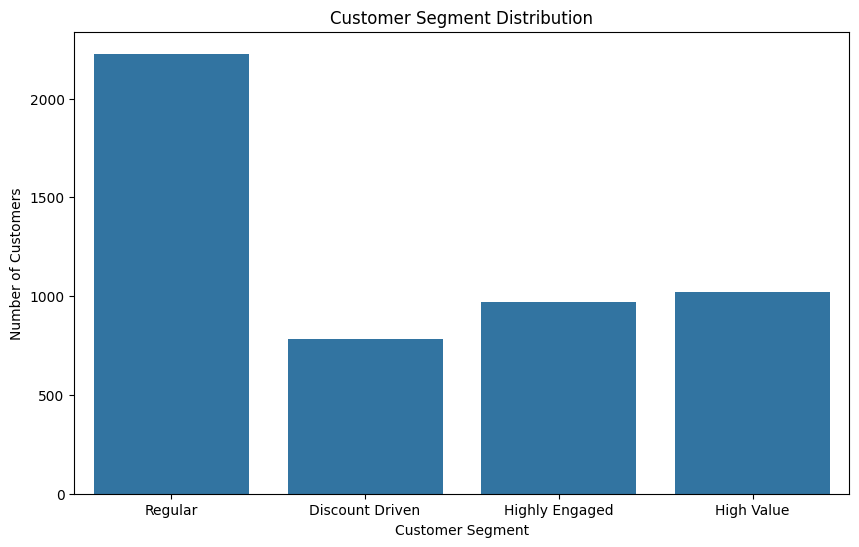

In [ ]:
#Customer Segment Distribution Plot
plt.figure(figsize=(10,6))

sns.countplot(
    data=customer_analysis,
    x='segment'
)

plt.title('Customer Segment Distribution')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
#Average lifetime value by segment
segment_value = (
    customer_analysis.groupby('segment')['lifetime_value']
    .mean()
    .reset_index()
)

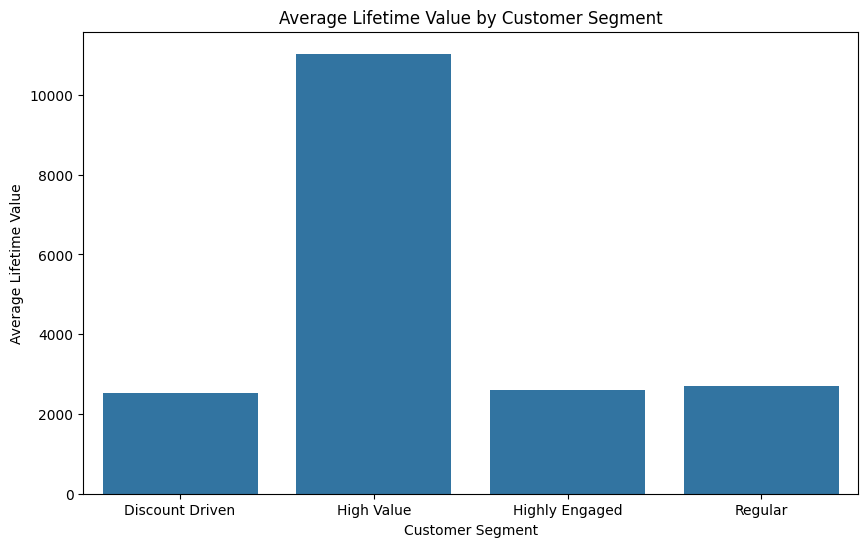

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_value,
    x='segment',
    y='lifetime_value'
)

plt.title('Average Lifetime Value by Customer Segment')

plt.xlabel('Customer Segment')
plt.ylabel('Average Lifetime Value')

plt.show()

Customer segmentation revealed four distinct behavioral groups.

Key findings:
- Regular customers represent the largest customer segment.
- Highly Engaged users demonstrate strong interaction behavior,
  although their lifetime value remains moderate.
- High Value customers generate significantly higher revenue
  compared to all other segments and represent the most strategically
  important customer group.
- Discount Driven customers contribute the lowest lifetime value,
  suggesting higher price sensitivity and lower profitability.

# Final Conclusions

The analysis explored customer purchasing behavior,
engagement patterns, revenue distribution, and customer segmentation
within the e-commerce dataset.

Key findings:
- Revenue distribution is highly right-skewed, with a limited number
  of high-value transactions contributing significantly to total revenue.
  
- Istanbul represents the strongest market by revenue,
  significantly outperforming all other cities.

- Customer engagement demonstrates a moderate relationship
  with spending behavior, although engagement alone is not
  a strong predictor of purchase amount.

- Delivery time and discount levels show relatively weak influence
  on customer satisfaction ratings.

- Customer segmentation identified four primary behavioral groups:
  Regular, Highly Engaged, High Value, and Discount Driven customers.

- High Value customers generate substantially greater lifetime value
  and represent the most strategically important segment.

Overall, the project demonstrates how behavioral analytics
and customer segmentation can support data-driven decision making
in e-commerce environments.

# Business Recommendations

- Focus retention strategies on High Value customers.
- Improve personalization for Highly Engaged users
  to increase conversion and lifetime value.
- Consider geographic expansion strategies based on
  strong city-level revenue performance.
- Further investigate factors influencing customer satisfaction,
  as operational metrics alone showed weak correlation with ratings.

In [ ]:
files.download('ecommerce_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
customer_analysis.to_csv(
    'customer_segmentation.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download('customer_segmentation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>